In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

In [8]:
train_data = pd.read_csv("data/train.csv")

In [9]:
data = train_data.copy()

data["Age"].fillna(data["Age"].median(), inplace=True)
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)

le = LabelEncoder()
data["Sex"] = le.fit_transform(data["Sex"])
data["Embarked"] = le.fit_transform(data["Embarked"])

data.drop(["Name", "Ticket", "Cabin", "PassengerId"], axis=1, inplace=True)

In [10]:
X = data.drop("Survived", axis=1)
y = data["Survived"]

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [13]:
y_pred_default = model.predict(X_val)

print("Default F1:", f1_score(y_val, y_pred_default))

Default F1: 0.7518796992481203


In [14]:
y_proba = model.predict_proba(X_val)[:, 1]

best_f1 = 0
best_threshold = 0

for t in np.arange(0.01, 0.99, 0.01):
    y_pred = (y_proba > t).astype(int)
    f1 = f1_score(y_val, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best F1:", best_f1)
print("Best threshold:", best_threshold)

Best F1: 0.8263473053892216
Best threshold: 0.28


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_proba = model.predict_proba(X_val)[:, 1]

y_pred = (y_proba > best_threshold).astype(int)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_val, y_val)

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_proba)

tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

print(f"train accuracy= {train_acc*100:.3f}%")
print(f"test accuracy= {test_acc*100:.3f}%\n")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}\n")

print(f"True Positives  (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives  (TN): {tn}")
print(f"False Negatives (FN): {fn}")

train accuracy= 87.500%
test accuracy= 81.564%

Accuracy:  0.8380
Precision: 0.7419
Recall:    0.9324
F1-score:  0.8263
ROC AUC:   0.8880

True Positives  (TP): 69
False Positives (FP): 24
True Negatives  (TN): 81
False Negatives (FN): 5


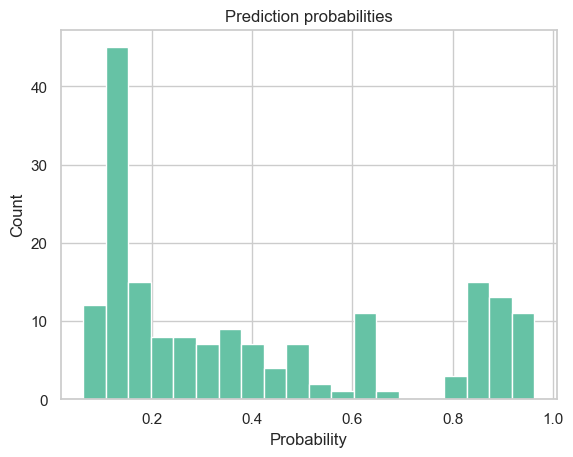

In [16]:
import matplotlib.pyplot as plt

plt.hist(y_proba, bins=20)
plt.title("Prediction probabilities")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()